# Background

Partial least squares correlation (PLSC) is a multivariate statistical technique that uses [compact singular value decomposition (SVD)](https://en.wikipedia.org/wiki/Singular_value_decomposition#Compact_SVD) to identify associations between a set of multivariate observations and a design matrix. The details of this technique in the context of neuroimaging can be found in [Krishnan et al. (2011)](https://doi.org/10.1016/j.neuroimage.2010.07.034).

The vocabulary of PLSC can be challenging, since different terms sometimes appear in different sources for the same underlying mathematical objects. Thus, to discuss the terminology used in `pyplsc`, we will also review the mathematics of PLSC.

## Mathematical overview and example

### Data and design matrices

The two basic ingredients to PLSC are (1) a data matrix $X$ with one row per observation and one column per observed variable, and (2) a design matrix $Y$ with one row per observation whose columns contain covariates or encode experimental conditions. In the simplest case, which we will consider here for expository purposes, $Y$ contains only covariates. To make this concrete, we will create and inspect a simulated $X$ and $Y$:

In [1]:
import numpy as np

np.random.seed(123)

n_obs = 4
n_var = 5
n_cov = 3
true_latent_var = 5*np.random.normal(size=(n_obs, 1)) # Data covary
X = true_latent_var + np.random.normal(size=(n_obs, n_var))
Y = true_latent_var + np.random.normal(size=(n_obs, n_cov))

Here, $X$ and $Y$ have the same number of rows:

In [2]:
X

array([[-6.00675327, -3.77671648, -7.85483226, -5.85706565, -4.16221676],
       [ 4.11998683,  4.30784108,  4.89201826,  6.47811686,  4.34782524],
       [ 0.97091053,  0.98054121,  3.62082257,  3.60167858,  2.41894639],
       [-7.14528717, -6.79410499, -6.04074154, -8.46730744, -6.35564452]])

In [3]:
Y

array([[-6.68203368, -6.06590452, -4.52104782],
       [ 3.55804653,  4.84665851,  4.12497234],
       [ 1.15927312, -1.38369662, -0.35664061],
       [-8.2313508 , -6.60401114, -7.70510925]])

### Correlation and SVD

Next, the correlations between the columns of $X$ and $Y$ are computed and stored in a new matrix $R$, to which compact SVD is applied:

$$R = USV^T$$

where $U$ and $V$ are orthonormal matrices of "left singular vectors" and "right singular vectors", respectively, and $S$ is a diagonal matrix of singular values.

`pyplsc` computes and decomposing $R$ internally when the `.fit()` method of a model of class `PLSC` is called:

In [4]:
from pyplsc import PLSC

mod = PLSC()
mod.fit(data=X, covariates=Y)

### Saliences

The singular vectors $U$ and $V$ are also called "saliences"; thus we might refer to $U$ as the "left saliences" ad $V$ as the "right saliences". For clarity, in the context of neuroimaging, the terms "brain saliences" for $V$ and "design saliences" for $U$ can be used [('Krishnan et al., 2011)](https://doi.org/10.1016/j.neuroimage.2010.07.034), which saves us having to remember an arbitrary left--right mapping. `pyplsc` refers to $U$ as the "design saliences" but uses the non-neuroimaging-specific term "data saliences" for $V$. After calling `.fit()`, these are accessible by the properties `design_sals_` and `data_sals_` (with the trailing underscores because these properties are added by fitting the model, following the scikit-learn convention):

In [5]:
mod.design_sals_

array([[-0.59266317,  0.68357283,  0.426003  ],
       [-0.56264137,  0.02710892, -0.82625649],
       [-0.57635497, -0.7293787 ,  0.3685399 ]])

In [6]:
mod.data_sals_

array([[-0.45449331, -0.08584571, -0.63766531],
       [-0.45392915, -0.5901328 , -0.20111844],
       [-0.42744766,  0.8003629 , -0.16236509],
       [-0.45031061, -0.02013286,  0.38956821],
       [-0.44932506, -0.0582038 ,  0.61221606]])

### Latent variables

PLSC can be interpreted as identifying pairs of latent variables with maximal covariance. If $U_{:,i}$ and $V_{:,i}$ are the $i$th columns of the design and data saliences, respectively, the values of the $i$th pair of these latent variables are estimated as $L_{Y,i} = YU_{:,i}$ and $L_{X,i} = XV_{:,i}$. In neuroimaging, $L_{Y,i}$ are called the "brain scores" and $L_{X,i}$ the "design scores", respectively, analogous to the principal component scores that can be computed in PCA. `pyplsc` also refers to $L_{Y,i}$ as the "design scores" but the documentation uses the non-neuroimaging specific term "data scores" for $L_{X,i}$.

Note that significance testing (via `.permute()`) is performed on the level of pairs of latent variables. Thus, in these tutorials, we might say "the first pair of latent variables is significant". Note also that computing $L_{Y,i}$ is only as simple as $YU_{:,i}$ when the observations are not stratified by experimental condition.

After fitting, the design scores are accessible via the `design_scores_` property, while the data scores can be computed via the `transform` method (which can also be applied to a new data array with the same number of columns as $X$):

In [8]:
design_scores = mod.design_scores_
data_scores = mod.transform()

There are 2 pairs of latent variables, thus two columns in each matrix of scores:

In [9]:
design_scores

array([[ 9.9788525 , -1.4345408 ,  0.49924011],
       [-7.21310205, -0.44509536, -0.96862769],
       [ 0.29701807,  1.01506316,  1.50570584],
       [13.03498637, -0.18581278, -0.88961322]])

In [10]:
data_scores

array([[ 12.30960766,  -3.18212168,   1.03531354],
       [-10.78979444,   0.63602538,   0.89762489],
       [ -5.14284803,   2.02267003,   1.47980124],
       [ 15.58229709,   0.3284249 ,  -0.28609435]])

We can see that the first pair of latent variables are indeed correlated with one another:

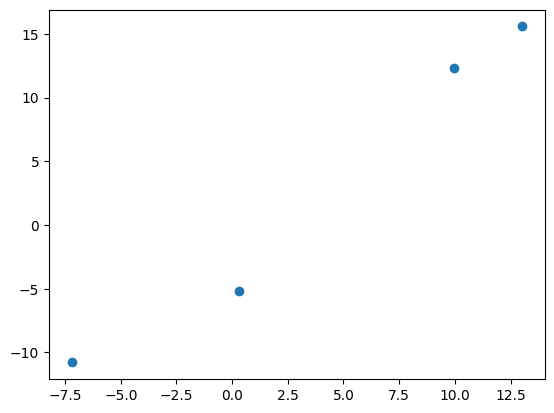

In [11]:
from matplotlib import pyplot as plt

plt.scatter(design_scores[:, 0], data_scores[:, 0])

## PLSC and BDA

We can use a similar approach to the one described above to analyze condition-wise differences rather than correlations with covariates. In this case, $R$ is a matrix of stacked condition-wise averages ("barycentres") rather than a correlation matrix. Within `pyplsc`, this approach is referred to as "barycentric discriminant analysis" (BDA; [Abdi and Williams, 2018](https://doi.org/10.1007/978-1-4614-7163-9_110192-2)); it is described in detail elsewhere in the documentation.

Unfortunately, here the terminology becomes even more confusing. At times, "PLSC" is used in a broad sense to refer to a _family_ of techniques including the method that decomposes a correlation matrix _and_ the method that decomposes stacked barycentres ([Krishnan et al., 2011](https://doi.org/10.1016/j.neuroimage.2010.07.034)). In this case, the former method is referred to as "behaviour PLSC"  or "seed PLSC" depending on whether the covariates in $Y$ are behavioural or neural variables, whereas the latter method is referred to as "mean-centred task PLSC". At other times, however, "PLSC" is used in a narrow sense to refer only to the method that decomposes a correlation matrix ([Abdi & Williams, 2012](doi.org/10.1007/978-1-62703-059-5_23)). To make matters yet more confusing, the main [Matlab software](https://github.com/McIntosh-Lab/PLS) used for PLSC in neuroimaging is simply called "PLS" ([McIntosh & Lobaugh, 2004](https://doi.org/10.1016/j.neuroimage.2004.07.020)), which obscures differences between partial least squares correlation, partial least squares regression, and partial least squares path modeling ([Krishnan et al., 2011](https://doi.org/10.1016/j.neuroimage.2010.07.034)).

Thus, there doesn't seem to be any single set of terms that simultaneously avoids being unfamiliar (in the way that "BDA" is not widely used), imprecise (in the way that "PLSC" has both a broad and a narrow sense), and potentially misleading (in the way that "behaviour PLSC" and "seed PLSC" are mathematically identical). The balance struck in `pyplsc` is as follows: for discoverability, the library is described as implementing broad-sense PLSC, which includes the technique of applying SVD to correlation matrices and the technique of applying SVD to stacked barycentres. Within `pyplsc`, the former technique is implemented in the `PLSC` class (whose name uses the narrow sense of "PLSC") and the latter technique is implemented in the `BDA` class (whose name is unambiguous).